# 02 · Feature engineering and model selection

Goal set in stage 1: **reduce MAE by at least 20 % versus the planner's current rule** (the 4-week moving average), measured on data the model never saw.

This notebook builds the features, chooses the feature set and the model family using the **validation** quarter only. The test quarter is not touched here.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import data_prep as dp, plot_style as ps

ps.apply()
pd.options.display.float_format = "{:,.2f}".format
IMG = Path.cwd().parent / "images"
DATA_PATH, DATA_MODE = dp.resolve_data_path()
print(f"Using {DATA_MODE} dataset: {DATA_PATH.name}")

import json
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
RANDOM_STATE = 649

Using full dataset: valle_central_ventas_semanales.csv


In [2]:
train, val, test = dp.prepare(DATA_PATH)
for name, part in [("train", train), ("validation", val), ("test", test)]:
    print(f"{name:<11} {part.fecha.min().date()} → {part.fecha.max().date()}  rows: {len(part):>7,}")

train       2023-02-27 → 2025-06-23  rows: 421,940
validation  2025-06-30 → 2025-09-22  rows:  53,040
test        2025-09-29 → 2025-12-22  rows:  53,040


## 1. Features

All time-based features are computed per product-store series and use **only past weeks** (`shift(1)` before any rolling window), so the week being forecast never leaks into its own inputs.

| Feature | Meaning |
|---|---|
| `lag_1`, `lag_2`, `lag_4` | Units sold 1, 2 and 4 weeks earlier |
| `media_movil_4`, `media_movil_8` | Mean of the previous 4 / 8 weeks |
| `std_movil_4` | Volatility of the previous 4 weeks |
| `semana_transcurrida` | Trend: weeks since the series started |
| calendar flags | December, payday (quincena), holiday season |
| product / store | category, perishable, price, promotion, urban/rural |

In [3]:
# Sanity check: lag_1 must equal the previous week's units of the same series
chk = pd.concat([train, val]).sort_values(dp.GROUP_KEYS + ["fecha"])
prev = chk.groupby(dp.GROUP_KEYS).unidades.shift(1)
same = prev.notna()
assert np.allclose(chk.loc[same, "lag_1"], prev[same]), "lag_1 is misaligned"
print("lag_1 verified against the previous week ✔")

lag_1 verified against the previous week ✔


## 2. Redundancy between numeric features (training data only)

In [4]:
corr = train[dp.NUMERIC_CANDIDATES].corr().abs()
pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
             .sort_values(ascending=False).rename("abs_corr").reset_index())
pairs.columns = ["feature_1", "feature_2", "abs_corr"]
display(pairs.head(6))
print("Pairs above 0.85:", (pairs.abs_corr > 0.85).sum())

,feature_1,feature_2,abs_corr
0,media_movil_4,media_movil_8,0.95
1,lag_2,media_movil_4,0.87
2,lag_1,media_movil_4,0.85
3,lag_4,media_movil_4,0.85
4,lag_4,media_movil_8,0.83
5,lag_2,media_movil_8,0.82


Pairs above 0.85: 4


The two moving averages are the most similar pair, and they carry largely the same information (recent level of demand). Rather than drop one on correlation alone, the decision is made **empirically**: train the same model with each and with both, and compare on validation.

In [5]:
BASE_NUMERIC = ["precio", "lag_1", "lag_2", "lag_4", "std_movil_4", "semana_transcurrida"]
FEATURE_SETS = {
    "4-week MA only": BASE_NUMERIC + ["media_movil_4"],
    "8-week MA only": BASE_NUMERIC + ["media_movil_8"],
    "both MAs":       BASE_NUMERIC + ["media_movil_4", "media_movil_8"],
}

def make_pipeline(numeric, model):
    prep = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), dp.CATEGORICAL),
        ("num", StandardScaler(), numeric),
    ], remainder="passthrough")          # boolean flags pass through as 0/1
    return Pipeline([("prep", prep), ("model", model)])

def cols(numeric):
    return dp.CATEGORICAL + numeric + dp.BOOLEAN

ablation = []
for name, numeric in FEATURE_SETS.items():
    pipe = make_pipeline(numeric, GradientBoostingRegressor(random_state=RANDOM_STATE))
    pipe.fit(train[cols(numeric)], train.unidades)
    pred = pipe.predict(val[cols(numeric)])
    ablation.append({"feature set": name, "n features": len(cols(numeric)),
                     "val MAE": mean_absolute_error(val.unidades, pred)})
ablation = pd.DataFrame(ablation)
ablation

,feature set,n features,val MAE
0,4-week MA only,15,19.09
1,8-week MA only,15,17.80
2,both MAs,16,17.81


In [6]:
# Rule: lowest validation MAE; if within 0.05 units of the best, prefer fewer features.
best_mae = ablation["val MAE"].min()
chosen = (ablation[ablation["val MAE"] <= best_mae + 0.05]
          .sort_values(["n features", "val MAE"]).iloc[0]["feature set"])
NUMERIC = FEATURE_SETS[chosen]
FEATURES = cols(NUMERIC)
print("Chosen feature set:", chosen)
print("Numeric features:", NUMERIC)

Chosen feature set: 8-week MA only
Numeric features: ['precio', 'lag_1', 'lag_2', 'lag_4', 'std_movil_4', 'semana_transcurrida', 'media_movil_8']


**Result:** the 8-week average alone is clearly better than the 4-week one (≈1.3 units lower MAE), and adding both gives nothing extra. The 8-week window smooths out one-off spikes (a payday week, a single promotion) that the 4-week window over-reacts to. The 4-week average stays in the project only as the **baseline**, the rule the planner uses today.

## 3. Baseline vs. linear regression vs. gradient boosting (validation)

In [7]:
def evaluate(y, pred, name):
    return {"model": name,
            "MAE": mean_absolute_error(y, pred),
            "RMSE": mean_squared_error(y, pred) ** 0.5,
            "WAPE %": dp.wape(y, pred) * 100}

lr = make_pipeline(NUMERIC, LinearRegression()).fit(train[FEATURES], train.unidades)
gb = make_pipeline(NUMERIC, GradientBoostingRegressor(random_state=RANDOM_STATE)).fit(train[FEATURES], train.unidades)

comparison = pd.DataFrame([
    evaluate(val.unidades, val.media_movil_4, "Baseline: 4-week moving average"),
    evaluate(val.unidades, lr.predict(val[FEATURES]), "Linear regression"),
    evaluate(val.unidades, gb.predict(val[FEATURES]), "Gradient boosting (default)"),
])
base_mae = comparison.loc[0, "MAE"]
comparison["MAE vs baseline %"] = (base_mae - comparison.MAE) / base_mae * 100
comparison

,model,MAE,RMSE,WAPE %,MAE vs baseline %
0,Baseline: 4-week moving average,23.26,37.24,35.42,0.00
1,Linear regression,19.94,30.99,30.36,14.28
2,Gradient boosting (default),17.80,28.13,27.10,23.47


**Model family decision.** Linear regression is cheaper and easier to explain, but gradient boosting captures non-linear interactions (promotion × category, December × perishables) and is the model that clears the ≥20 % target on validation. Gradient boosting moves forward to tuning; linear regression stays documented as the interpretable reference.

## 4. What the model relies on

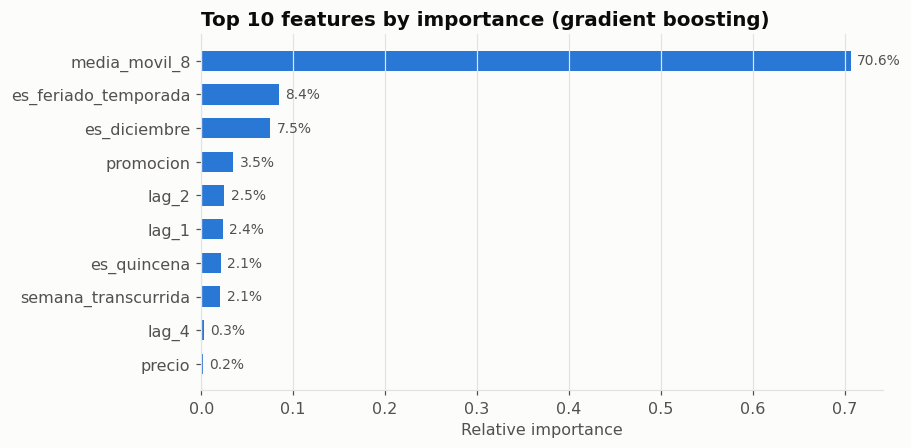

In [8]:
names = (list(gb.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(dp.CATEGORICAL))
         + NUMERIC + dp.BOOLEAN)
importance = pd.Series(gb.named_steps["model"].feature_importances_, index=names).sort_values()
top = importance.tail(10)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(top.index, top.values, color=ps.BLUE, height=0.6)
ax.set_title("Top 10 features by importance (gradient boosting)")
ax.set_xlabel("Relative importance")
ax.grid(axis="y", visible=False)
for i, v in enumerate(top.values):
    ax.text(v + top.max() * 0.01, i, f"{v:.1%}", va="center", color=ps.INK_2, fontsize=9)
fig.savefig(IMG / "feature_importance.png")
plt.show()

## 5. Fairness check: urban vs. rural stores (validation)

Defined *before* looking at results in stage 1: compare WAPE between urban and rural stores; the gap must stay **≤ 10 percentage points**, so rural stores aren't systematically under-supplied.

In [9]:
val_eval = val.assign(pred=gb.predict(val[FEATURES]))
fair = val_eval.groupby("tipo_sucursal").apply(lambda g: dp.wape(g.unidades, g.pred) * 100, include_groups=False)
display(fair.rename("WAPE %").to_frame())
print(f"Gap: {fair.max() - fair.min():.1f} pp (threshold 10 pp)")

,WAPE %
tipo_sucursal,
rural,28.89
urbana,26.54


Gap: 2.4 pp (threshold 10 pp)


In [10]:
# Hand the decisions to notebook 03
config = {"numeric": NUMERIC, "categorical": dp.CATEGORICAL, "boolean": dp.BOOLEAN,
          "feature_set": chosen, "random_state": RANDOM_STATE}
(Path.cwd().parent / "models").mkdir(exist_ok=True)
with open(Path.cwd().parent / "models" / "feature_config.json", "w") as f:
    json.dump(config, f, indent=2)
print(json.dumps(config, indent=2))

{
  "numeric": [
    "precio",
    "lag_1",
    "lag_2",
    "lag_4",
    "std_movil_4",
    "semana_transcurrida",
    "media_movil_8"
  ],
  "categorical": [
    "categoria",
    "tipo_sucursal"
  ],
  "boolean": [
    "promocion",
    "promocion_sin_registro",
    "es_feriado_temporada",
    "es_quincena",
    "es_diciembre",
    "perecedero"
  ],
  "feature_set": "8-week MA only",
  "random_state": 649
}
